In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

raw_path = "global_ads_performance_dataset.csv"
df = pd.read_csv(raw_path, parse_dates=["date"])

df.head(10)

,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.68,10.41
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.07,2.06
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.07,6.45
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39
5,2024-10-15,TikTok Ads,Search,Fintech,Canada,17666,724,0.0410,0.37,267.88,23,11.65,5220.85,19.49
6,2024-08-14,Meta Ads,Video,Fintech,USA,118252,3748,0.0317,0.42,1574.16,152,10.36,12838.56,8.16
7,2024-04-05,TikTok Ads,Search,EdTech,UAE,92939,5176,0.0557,0.66,3416.16,388,8.80,96298.69,28.19
8,2024-04-17,Meta Ads,Display,EdTech,Germany,30939,937,0.0303,0.59,552.83,63,8.78,16531.03,29.90
9,2024-11-13,Google Ads,Shopping,Fintech,USA,8748,362,0.0414,1.21,438.02,10,43.80,966.57,2.21


In [18]:
print("Data shape:", df.shape)
df.info()
print(df.describe(include="all"))
print("\nMissing values per column:")
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Data shape: (1800, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1800 non-null   datetime64[us]
 1   platform       1800 non-null   str           
 2   campaign_type  1800 non-null   str           
 3   industry       1800 non-null   str           
 4   country        1800 non-null   str           
 5   impressions    1800 non-null   int64         
 6   clicks         1800 non-null   int64         
 7   CTR            1800 non-null   float64       
 8   CPC            1800 non-null   float64       
 9   ad_spend       1800 non-null   float64       
 10  conversions    1800 non-null   int64         
 11  CPA            1800 non-null   float64       
 12  revenue        1800 non-null   float64       
 13  ROAS           1800 non-null   float64       
dtypes: datetime64[us](1), float64(6), int64(3), str(4)
memory us

In [19]:
numeric_cols = ["impressions", "clicks", "CTR", "CPC", "ad_spend", "conversions", "CPA", "revenue", "ROAS"]

cf = df.copy()
cf.columns = cf.columns.str.strip()
for col in ["platform", "campaign_type", "industry", "country"]:
    cf[col] = cf[col].astype(str).str.strip()

cf["date"] = pd.to_datetime(cf["date"], errors="coerce")
for col in numeric_cols:
    cf[col] = pd.to_numeric(cf[col], errors="coerce")

cf = cf.drop_duplicates()
cf = cf.dropna(subset=["date", "platform", "impressions", "clicks", "ad_spend", "revenue"])

cf["CTR"] = cf["clicks"] / cf["impressions"]
cf["CPA"] = np.where(cf["conversions"] > 0, cf["ad_spend"] / cf["conversions"], np.nan)
cf["ROAS"] = np.where(cf["ad_spend"] > 0, cf["revenue"] / cf["ad_spend"], np.nan)

print("After cleaning:")
print(cf.isnull().sum())
cf.head(10)

After cleaning:
date             0
platform         0
campaign_type    0
industry         0
country          0
impressions      0
clicks           0
CTR              0
CPC              0
ad_spend         0
conversions      0
CPA              0
revenue          0
ROAS             0
dtype: int64


,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.035284,1.26,2662.38,159,16.744528,4803.43,1.804186
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.038493,1.18,6159.60,411,14.986861,64126.68,10.410851
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.064899,0.85,5092.35,267,19.072472,10489.07,2.059770
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.070694,1.32,7834.20,296,26.466892,50505.07,6.446742
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.048896,1.93,8663.77,107,80.969813,3369.53,0.388922
5,2024-10-15,TikTok Ads,Search,Fintech,Canada,17666,724,0.040983,0.37,267.88,23,11.646957,5220.85,19.489510
6,2024-08-14,Meta Ads,Video,Fintech,USA,118252,3748,0.031695,0.42,1574.16,152,10.356316,12838.56,8.155816
7,2024-04-05,TikTok Ads,Search,EdTech,UAE,92939,5176,0.055692,0.66,3416.16,388,8.804536,96298.69,28.189163
8,2024-04-17,Meta Ads,Display,EdTech,Germany,30939,937,0.030285,0.59,552.83,63,8.775079,16531.03,29.902556
9,2024-11-13,Google Ads,Shopping,Fintech,USA,8748,362,0.041381,1.21,438.02,10,43.802000,966.57,2.206680


In [20]:
df = cf.copy()

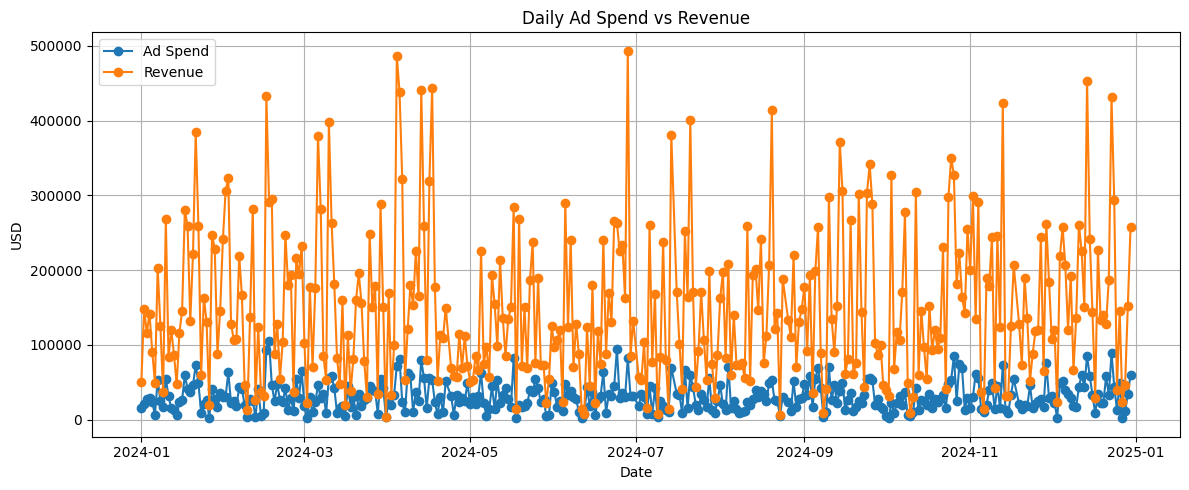

In [21]:
daily = df.groupby("date").agg(ad_spend=("ad_spend", "sum"), revenue=("revenue", "sum")).reset_index()
plt.figure(figsize=(12, 5))
plt.plot(daily["date"], daily["ad_spend"], marker="o", label="Ad Spend")
plt.plot(daily["date"], daily["revenue"], marker="o", label="Revenue")
plt.title("Daily Ad Spend vs Revenue")
plt.xlabel("Date")
plt.ylabel("USD")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

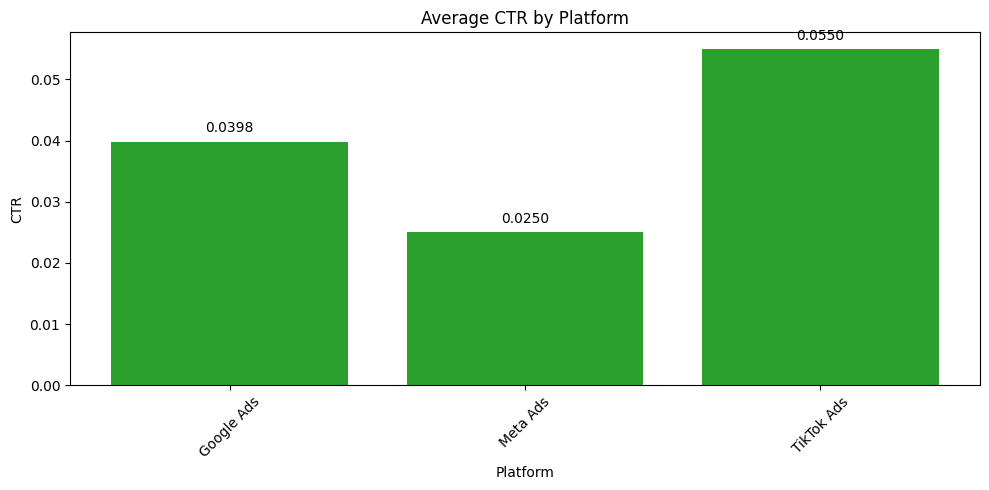

In [22]:
platform_ctr = df.groupby("platform").agg(CTR=("CTR", "mean")).reset_index()
plt.figure(figsize=(10, 5))
plt.bar(platform_ctr["platform"], platform_ctr["CTR"], color="#2ca02c")
for i, v in enumerate(platform_ctr["CTR"]):
    plt.text(i, v + 0.001, f"{v:.4f}", ha="center", va="bottom")
plt.title("Average CTR by Platform")
plt.xlabel("Platform")
plt.ylabel("CTR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

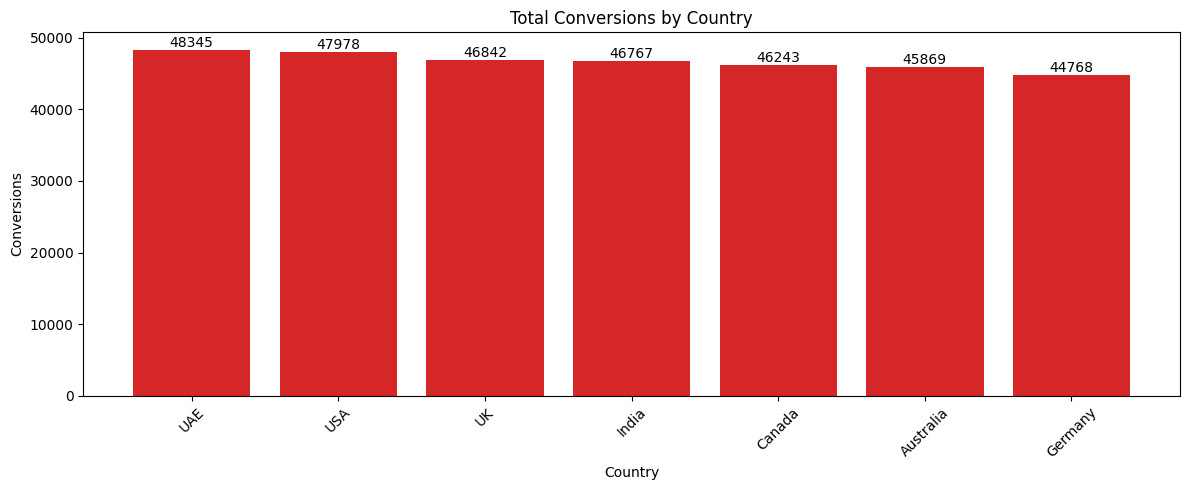

In [24]:
country_conversions = (
    df.groupby("country").agg(conversions=("conversions", "sum")).reset_index().sort_values("conversions", ascending=False)
)
plt.figure(figsize=(12, 5))
plt.bar(country_conversions["country"], country_conversions["conversions"], color="#d62728")
for i, v in enumerate(country_conversions["conversions"]):
    plt.text(i, v + 1, f"{int(v)}", ha="center", va="bottom")
plt.title("Total Conversions by Country")
plt.xlabel("Country")
plt.ylabel("Conversions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

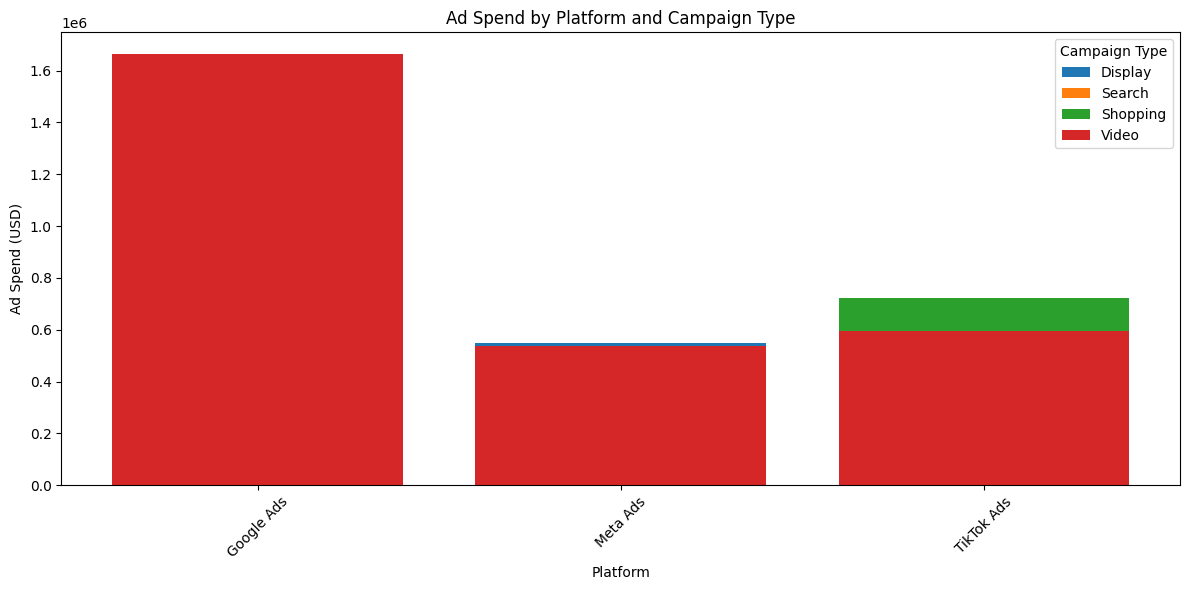

In [23]:
platform_spend = (
    df.groupby(["platform", "campaign_type"]).agg(ad_spend=("ad_spend", "sum")).reset_index()
)
plt.figure(figsize=(12, 6))
for campaign in platform_spend["campaign_type"].unique():
    subset = platform_spend[platform_spend["campaign_type"] == campaign]
    plt.bar(subset["platform"], subset["ad_spend"], label=campaign)
plt.title("Ad Spend by Platform and Campaign Type")
plt.xlabel("Platform")
plt.ylabel("Ad Spend (USD)")
plt.xticks(rotation=45)
plt.legend(title="Campaign Type")
plt.tight_layout()
plt.show()